In [1]:
import numpy as np
import pandas as pd
import scipy as sp
import tensorflow as tf
from scipy import stats
import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential, Model
from tensorflow import keras
from keras import layers
import keras.backend as K
import matplotlib.pyplot as plt
import japanize_matplotlib
import math
from sklearn.metrics import mean_squared_error
from statistics import mean
import pickle
import calendar
import random
import os
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping
from keras.callbacks import LearningRateScheduler
from keras.callbacks import ModelCheckpoint
import copy
from tensorflow.keras.utils import plot_model

from collections import defaultdict

2023-03-29 14:26:08.713981: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-03-29 14:26:08.756665: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-03-29 14:26:09.531644: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


# ------------------------

In [2]:
def day_add(ymd,plus_day): #引数は、(タプル or datatime型,整数値)、戻り値はdatatime型
    if type(ymd)!=datetime.datetime:
        y1,m1,d1=ymd
        ymd=datetime.datetime(y1,m1,d1)
    return ymd+datetime.timedelta(days=plus_day)

In [3]:
def str_to_datetime(before): #引数はstr型、戻り値はdatatime型
    return datetime.datetime.strptime(before, '%Y/%m/%d')

In [4]:
#損失関数のグラフを表示
def draw_history(history,y_lim,val): #引数は、(学習の過程の履歴,y軸の上限値,validationデータの有無)
    plt.plot(history.history['loss'])
    if val:
        plt.plot(history.history['val_loss'])
    plt.ylim([0, y_lim])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    if val:
        plt.legend(['Train',"validation"], loc='upper left')
    else:
        plt.legend(['Train'], loc='upper left')
    plt.show()

In [5]:
#95%信頼区間を求める
def MeanCI(data): #引数は、リスト、戻り値は95%信頼区間の下と上を表す1x2のリスト
    u_var = np.var(data, ddof=1)
    s_mean = np.mean(data)
    deg_of_freedom = len(data)-1
    # t分布の両側2.5%で区間推定する
    bottom, up = sp.stats.t.interval(
        alpha=0.95, # 信頼区間
        loc=s_mean,  # 標本平均
        scale=np.sqrt(u_var/len(data)), # 標準誤差(推定量の標準偏差)
        df=deg_of_freedom # 自由度
    )
    return [bottom,up]

In [6]:
def TimeSeries(dataset,date): #引数は(データフレーム,datatime型の日付)、戻り値はデータフレームに日付の情報を加えたデータフレーム
    date_set=pd.date_range(date, periods=len(dataset), freq='d')
    dataset=dataset.set_index(date_set)
    return dataset

In [7]:
def calc_MAE(d1,d2): #引数は(リスト、リスト)、戻り値は2つのリストのMAE(平均絶対値誤差)
    res=0
    for i in range(len(d1)):
        res+=abs(d1[i]-d2[i])
    return res/len(d1)

# -----------------------------

In [8]:
LOOK_BACK = 14 # 予測に使うタイムステップ数
EPOCHS = 50 # 訓練時のエポック数
BATCH_SIZE = 32 # 訓練時のバッチサイズ(元：32)
DATA_FILE_NAME = 'Tokyo_future_omicron_22_normal_v3_sep_4(マスク考慮無し).xlsx' # データを読み込むファイル名

In [9]:
Days=14 #Inputの長さ
Days2=14 #Outputの長さ
SelectedInputs=[4,13,14,17,22] #Inputで使う変数の列番号
SelectedOutput=17 #Outputで使う変数の列番号

FileFirstDate=str_to_datetime("2020/1/26")
FileEndDate=str_to_datetime("2023/12/31")

StartTrainingDate=str_to_datetime("2021/1/1") #いつから訓練するか(2021/1/1)
StartTestingDate=str_to_datetime("2023/2/16") #いつから予測するか

DataLength=(FileEndDate-FileFirstDate).days+2
DataShift=(StartTrainingDate-FileFirstDate).days+2
Dd=DataLength-DataShift-Days+2

t=(StartTestingDate-StartTrainingDate).days #訓練データをStartingDate前日までにするために使用
S=(FileEndDate-StartTestingDate).days+1 #InputTestをFileEndDateまでにするために使用

# DataLength,DataShift,t,S

In [10]:
exponentiation=1 #10のとき対数変換

NewDate=day_add(StartTrainingDate,5*30) #実測値(青線)をプロットし始める日
NewDate1=day_add(StartTrainingDate,365+30*3) #予測結果(赤線)をプロットし始める日

MOSTUPDATED=1437 #エクセルのここの行までデータが入っている(感染者数は途中から0だったりする)1131
ttt=429
# NewDate1,NewDate

In [11]:
data=pd.read_excel(DATA_FILE_NAME, sheet_name="Data", header=None, skiprows=24, skipfooter=41, usecols=SelectedInputs, engine="openpyxl")
index_date=pd.date_range('2020-02-18', periods=len(data), freq='d')
data=data.set_index(index_date)
data.loc[StartTestingDate:,17]=0.2 #StartingTestingDate(予測開始日)から感染者数を0にセット
data

,4,13,14,17,22
2020-02-18,0.756349,0.200000,0.314050,0.200045,0.000000
2020-02-19,0.730716,0.200000,0.294215,0.200045,0.000000
2020-02-20,0.739403,0.200000,0.328926,0.200000,0.000000
2020-02-21,0.729916,0.200000,0.396694,0.200045,0.000000
2020-02-22,0.710940,0.200000,0.352066,0.200015,0.000000
...,...,...,...,...,...
2023-12-27,0.740947,0.779089,0.565289,0.200000,0.096675
2023-12-28,0.728155,0.782391,0.761983,0.200000,0.089541
2023-12-29,0.689779,0.139662,0.800000,0.200000,0.083014
2023-12-30,0.613026,0.139662,0.732231,0.200000,0.103823


In [12]:
use_data=data[StartTrainingDate:FileEndDate] #使用するデータ
use_data

,4,13,14,17,22
2021-01-01,0.228565,0.210471,0.241322,0.211785,0.000000
2021-01-02,0.390269,0.210590,0.247934,0.212320,0.000000
2021-01-03,0.417334,0.210683,0.236364,0.212275,0.000000
2021-01-04,0.469321,0.210751,0.251240,0.213449,0.000000
2021-01-05,0.501154,0.210793,0.224793,0.219542,0.000000
...,...,...,...,...,...
2023-12-27,0.740947,0.779089,0.565289,0.200000,0.096675
2023-12-28,0.728155,0.782391,0.761983,0.200000,0.089541
2023-12-29,0.689779,0.139662,0.800000,0.200000,0.083014
2023-12-30,0.613026,0.139662,0.732231,0.200000,0.103823


In [13]:
InputTrain=use_data[SelectedInputs][:t] #訓練するデータ
InputTrain

,4,13,14,17,22
2021-01-01,0.228565,0.210471,0.241322,0.211785,0.000000
2021-01-02,0.390269,0.210590,0.247934,0.212320,0.000000
2021-01-03,0.417334,0.210683,0.236364,0.212275,0.000000
2021-01-04,0.469321,0.210751,0.251240,0.213449,0.000000
2021-01-05,0.501154,0.210793,0.224793,0.219542,0.000000
...,...,...,...,...,...
2023-02-11,0.663703,0.689944,0.259504,0.211874,0.330562
2023-02-12,0.634194,0.689944,0.259504,0.212037,0.329565
2023-02-13,0.611297,0.689944,0.236364,0.233169,0.328333
2023-02-14,0.624206,0.689944,0.233058,0.227611,0.327470


In [14]:
OutputTrain=use_data[SelectedOutput][:t] #訓練データに対する答え
OutputTrain

2021-01-01    0.211785
2021-01-02    0.212320
2021-01-03    0.212275
2021-01-04    0.213449
2021-01-05    0.219542
                ...   
2023-02-11    0.211874
2023-02-12    0.212037
2023-02-13    0.233169
2023-02-14    0.227611
2023-02-15    0.221607
Freq: D, Name: 17, Length: 776, dtype: float64

In [15]:
InputTest=use_data[SelectedInputs][:t+S] #テストするデータ
InputTest

,4,13,14,17,22
2021-01-01,0.228565,0.210471,0.241322,0.211785,0.000000
2021-01-02,0.390269,0.210590,0.247934,0.212320,0.000000
2021-01-03,0.417334,0.210683,0.236364,0.212275,0.000000
2021-01-04,0.469321,0.210751,0.251240,0.213449,0.000000
2021-01-05,0.501154,0.210793,0.224793,0.219542,0.000000
...,...,...,...,...,...
2023-12-27,0.740947,0.779089,0.565289,0.200000,0.096675
2023-12-28,0.728155,0.782391,0.761983,0.200000,0.089541
2023-12-29,0.689779,0.139662,0.800000,0.200000,0.083014
2023-12-30,0.613026,0.139662,0.732231,0.200000,0.103823


In [16]:
#dataframeからnumpy配列へ変換
InputTrain_list=InputTrain.to_numpy().tolist()
OutputTrain_list=OutputTrain.to_numpy().tolist()
InputTest_list=InputTest.to_numpy().tolist()

In [17]:
TrainingDataSingle=[[InputTrain_list[i:i+Days],OutputTrain_list[i+Days:i+Days+Days2]] for i in range(len(InputTrain)-Days-Days2+1)]
TrainingData_input=[tr[0] for tr in TrainingDataSingle]
TrainingData_output=[tr[1] for tr in TrainingDataSingle]

TestingData=[InputTest_list[i:i+Days] for i in range(Dd)]

In [18]:
alltmp=pd.read_excel(DATA_FILE_NAME, sheet_name="Data", header=None, engine="openpyxl")
VV=alltmp[[60,61,62,63,64,65]][15:16] #感染力の表的なやつ(たぶん)
VV

,60,61,62,63,64,65
15,9.12,6.08,3.2,3.2,1.6,1.1


In [19]:
if SelectedOutput==17: TC=43

In [20]:
#2023/2/22データ
MaxV=alltmp[TC][1449:1450].to_numpy().tolist()[0] #今までの最高感染者数
MinV=alltmp[TC][1450:1451].to_numpy().tolist()[0] #今までの最低感染者数
LB=alltmp[TC][1452:1453].to_numpy().tolist()[0] #MinMaxScalerの下限の値
UB=alltmp[TC][1453:1454].to_numpy().tolist()[0] #MinMaxScalerの上限の値
MaxV,MinV,LB,UB

(40375, 0, 0.2, 0.8)

In [114]:
def model_essam():
    input = keras.Input(shape=(LOOK_BACK,5), name='Input')

    lstm1 = layers.LSTM(300, return_sequences=True, name='LSTM1')(input)
    lstm2 = layers.LSTM(300, return_sequences=True, name='LSTM2')(lstm1)
    lstm3 = layers.LSTM(300, return_sequences=True, name='LSTM3')(lstm2)

    sr3 = K.reverse(lstm2, axes=1)
    lstm4 = layers.LSTM(300, return_sequences=True, name='LSTM4')(sr3)
    lstm5 = layers.LSTM(300, return_sequences=True, name='LSTM5')(lstm4)
    sr4 = K.reverse(lstm5, axes=1)

    sr1 = K.reverse(lstm1, axes=1)
    lstm6 = layers.LSTM(300, return_sequences=True, name='LSTM6')(sr1)
    sr2 = K.reverse(lstm6, axes=1)

    lstm7 = layers.LSTM(300, return_sequences=True, name='LSTM7')(input)
    lstm8 = layers.LSTM(300, return_sequences=True, name='LSTM8')(lstm7)

    cat = layers.concatenate([lstm3,lstm8,sr2,sr4], name='cat')

    Seq1 = layers.Lambda(lambda c: c[:,0:13,:], name='Seq1')(cat)
    
    Seq2=layers.Flatten()(Seq1)
    
    Lin1a = layers.Dense(3000, name='Lin1a')(Seq2)
    BN1a = layers.BatchNormalization(momentum=0.9, name='BN1a')(Lin1a) #momentum default:0.9 or 0.1

    Lin2a = layers.Dense(3000, name='Lin2a')(BN1a)
    BN2a = layers.BatchNormalization(momentum=0.9, name='BN2a')(Lin2a)

    Lin3a = layers.Dense(1500, name='Lin3a')(BN2a)
    BN3a = layers.BatchNormalization(momentum=0.9, name='BN3a')(Lin3a)
    Lin4a = layers.Dense(LOOK_BACK, name='Lin4a')(BN3a)
    La = layers.Activation('sigmoid', name='La')(Lin4a)


    # モデルをコンパイル
    model = keras.Model(inputs=input, outputs=La, name='CovidNet')
    model.compile(loss='mean_squared_error', optimizer=keras.optimizers.Adam(5.0*10**(-4))) #defaultでlr=10**-3
    model.summary()
    
    return model

In [101]:
# set_seed(1234) #seed固定(再現性が欲しいときに使用)
model=model_essam()

2023-03-29 15:42:59.229807: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-03-29 15:42:59.231433: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-03-29 15:42:59.233135: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

Model: "CovidNet"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 Input (InputLayer)             [(None, 14, 5)]      0           []                               
                                                                                                  
 LSTM1 (LSTM)                   (None, 14, 300)      367200      ['Input[0][0]']                  
                                                                                                  
 LSTM2 (LSTM)                   (None, 14, 300)      721200      ['LSTM1[0][0]']                  
                                                                                                  
 tf.reverse_32 (TFOpLambda)     (None, 14, 300)      0           ['LSTM2[0][0]']                  
                                                                                           

2023-03-29 15:43:01.454058: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-03-29 15:43:01.455677: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-03-29 15:43:01.457538: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

In [102]:
modelCheckpoint = ModelCheckpoint(filepath = 'XXX.h5',monitor='loss',verbose=1,save_best_only=True,
                                  save_weights_only=False,mode='min',period=1) #lossが最小となったときのモデルを保存

history = model.fit(np.array(TrainingData_input), np.array(TrainingData_output), epochs=EPOCHS+30, 
                    batch_size=BATCH_SIZE,callbacks=[modelCheckpoint],verbose=1)

Epoch 1/80


2023-03-29 15:43:01.839467: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-03-29 15:43:01.841084: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-03-29 15:43:01.842199: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

2023-03-29 15:43:05.145013: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-03-29 15:43:05.146493: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-03-29 15:43:05.147782: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

24/24 [==============================] - ETA: 0s - loss: 0.1410
Epoch 1: loss improved from inf to 0.14096, saving model to XXX.h5
24/24 [==============================] - 14s 214ms/step - loss: 0.1410
Epoch 2/80
24/24 [==============================] - ETA: 0s - loss: 0.0651
Epoch 2: loss improved from 0.14096 to 0.06510, saving model to XXX.h5
24/24 [==============================] - 5s 211ms/step - loss: 0.0651
Epoch 3/80
24/24 [==============================] - ETA: 0s - loss: 0.0348
Epoch 3: loss improved from 0.06510 to 0.03476, saving model to XXX.h5
24/24 [==============================] - 5s 210ms/step - loss: 0.0348
Epoch 4/80
24/24 [==============================] - ETA: 0s - loss: 0.0148
Epoch 4: loss improved from 0.03476 to 0.01480, saving model to XXX.h5
24/24 [==============================] - 5s 210ms/step - loss: 0.0148
Epoch 5/80
24/24 [==============================] - ETA: 0s - loss: 0.0076
Epoch 5: loss improved from 0.01480 to 0.00759, saving model to XXX.h5
24/2

24/24 [==============================] - 4s 152ms/step - loss: 0.0028
Epoch 42/80
24/24 [==============================] - ETA: 0s - loss: 0.0029
Epoch 42: loss did not improve from 0.00263
24/24 [==============================] - 4s 150ms/step - loss: 0.0029
Epoch 43/80
24/24 [==============================] - ETA: 0s - loss: 0.0031
Epoch 43: loss did not improve from 0.00263
24/24 [==============================] - 4s 151ms/step - loss: 0.0031
Epoch 44/80
24/24 [==============================] - ETA: 0s - loss: 0.0026
Epoch 44: loss improved from 0.00263 to 0.00258, saving model to XXX.h5
24/24 [==============================] - 5s 210ms/step - loss: 0.0026
Epoch 45/80
24/24 [==============================] - ETA: 0s - loss: 0.0027
Epoch 45: loss did not improve from 0.00258
24/24 [==============================] - 4s 150ms/step - loss: 0.0027
Epoch 46/80
24/24 [==============================] - ETA: 0s - loss: 0.0027
Epoch 46: loss did not improve from 0.00258
24/24 [===============

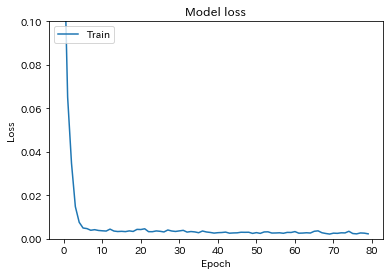

In [103]:
draw_history(history,y_lim=0.1,val=False)

In [104]:
x2=model.predict(TestingData) #テストデータを入力して予測
x2norm=(x2-LB)*(MaxV-MinV)/(UB-LB)+MinV #予測結果を逆正規化して単位を[人]に
x2norm

2023-03-29 15:48:32.188351: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-03-29 15:48:32.190156: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-03-29 15:48:32.191761: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

34/34 [==============================] - 5s 61ms/step


array([[   628.60364 ,   3563.9167  ,   6258.033   , ...,   3730.569   ,
          1227.666   ,   1380.4962  ],
       [   461.62198 ,   2978.3179  ,   5661.5166  , ...,   2816.1653  ,
           461.18283 ,    438.57242 ],
       [    66.399376,   2404.6384  ,   5207.4453  , ...,   2317.645   ,
           -53.079193,   -294.80182 ],
       ...,
       [-13449.957   , -13453.114   , -13450.048   , ..., -13457.625   ,
        -13458.222   , -13458.31    ],
       [-13446.222   , -13448.427   , -13439.203   , ..., -13456.345   ,
        -13458.059   , -13458.277   ],
       [-13435.517   , -13429.384   , -13389.516   , ..., -13449.262   ,
        -13457.258   , -13458.121   ]], dtype=float32)

In [105]:
#すべてnanで埋まった空の行列x3を作成
a,b=np.shape(x2norm)
x3=np.empty((a+b-1,b))
x3[:]=np.nan
np.shape(x3)

(1095, 14)

In [106]:
#予測結果を代入し、何日のデータが何人と予測されたかわかりやすくする
for i in range(b):
    x3[i:a+i,i]=x2norm[:,i]
x3

array([[   628.6036377 ,             nan,             nan, ...,
                    nan,             nan,             nan],
       [   461.62197876,   3563.91674805,             nan, ...,
                    nan,             nan,             nan],
       [    66.39937592,   2978.31787109,   6258.03320312, ...,
                    nan,             nan,             nan],
       ...,
       [            nan,             nan,             nan, ...,
        -13449.26171875, -13458.05859375, -13458.30957031],
       [            nan,             nan,             nan, ...,
                    nan, -13457.2578125 , -13458.27734375],
       [            nan,             nan,             nan, ...,
                    nan,             nan, -13458.12109375]])

In [107]:
a=np.average(x3[Days-1:Dd,:],axis=1) #平均
b=np.max(x3[Days-1:Dd,:],axis=1)     #最大値
c=np.min(x3[Days-1:Dd,:],axis=1)     #最小値
d=np.array([MeanCI(tmp) for tmp in x3[Days-1:Dd,:]]) #95%信頼区間
a[a<0]=0
b[b<0]=0
c[c<0]=0
d[d<0]=0

x=np.array([[a[i],b[i],c[i],d[i][0],d[i][1]] for i in range(len(a))])
if exponentiation==10: x=exponentiation**x
x=pd.DataFrame(x)
x #StartTrainingDate+26(=2021/1/27)~FileEndDate(=2023/12/31)までの予測値

,0,1,2,3,4
0,1556.369195,4117.959473,0.0,579.094821,2533.643568
1,1460.180371,4177.795898,0.0,466.710499,2453.650243
2,1328.243279,4368.829102,0.0,265.140013,2391.346544
3,1113.288572,4466.576660,0.0,0.000000,2263.932437
4,870.993020,4255.717773,0.0,0.000000,2061.085952
...,...,...,...,...,...
1064,0.000000,0.000000,0.0,0.000000,0.000000
1065,0.000000,0.000000,0.0,0.000000,0.000000
1066,0.000000,0.000000,0.0,0.000000,0.000000
1067,0.000000,0.000000,0.0,0.000000,0.000000


In [108]:
realvalue=pd.read_excel(DATA_FILE_NAME, sheet_name="Data", header=None, engine="openpyxl")[[TC-1,TC]][MOSTUPDATED-(FileEndDate-NewDate).days-1:MOSTUPDATED]
rv=TimeSeries(realvalue.drop(42,axis=1),NewDate) #感染者数の実測値
rvavg=TimeSeries(realvalue.drop(43,axis=1),NewDate) #感染者数の7日間平均値
rv

,43
2021-05-31,259
2021-06-01,471
2021-06-02,487
2021-06-03,509
2021-06-04,472
...,...
2023-12-27,NaN
2023-12-28,NaN
2023-12-29,NaN
2023-12-30,NaN


In [109]:
# VacEff=pd.read_excel(DATA_FILE_NAME, sheet_name="Data", header=None, engine="openpyxl")[[22]][343-1:MOSTUPDATED]
# VE=TimeSeries(VacEff,NewDate) #ワクチン効果のデータ
# VE

In [110]:
adjust=(NewDate1-day_add(StartTrainingDate,26)).days
p=TimeSeries(x[:][[0]][adjust:],NewDate1)
max=TimeSeries(x[:][[1]][adjust:],NewDate1)
min=TimeSeries(x[:][[2]][adjust:],NewDate1)
min95=TimeSeries(x[:][[3]][adjust:],NewDate1)
max95=TimeSeries(x[:][[4]][adjust:],NewDate1)
p #予測結果

,0
2022-04-01,6726.000017
2022-04-02,6168.491926
2022-04-03,6019.769008
2022-04-04,6427.487863
2022-04-05,7187.192610
...,...
2023-12-27,0.000000
2023-12-28,0.000000
2023-12-29,0.000000
2023-12-30,0.000000


In [111]:
print("City: Tokyo & Data:",SelectedInputs,"->",SelectedOutput)
print("Training:",StartTrainingDate,"->",day_add(StartTestingDate,-14-1))
print("Val:[",MinV,",",MaxV,"] and Scale:[",LB,",",UB,"]")
print("Variant weights:",VV)
print("Days are:",Days,"and",Days2)
print("Epochs:",EPOCHS,"& BS:",BATCH_SIZE)

City: Tokyo & Data: [4, 13, 14, 17, 22] -> 17
Training: 2021-01-01 00:00:00 -> 2023-02-01 00:00:00
Val:[ 0 , 40375 ] and Scale:[ 0.2 , 0.8 ]
Variant weights:       60    61   62   63   64   65
15  9.12  6.08  3.2  3.2  1.6  1.1
Days are: 14 and 14
Epochs: 50 & BS: 32


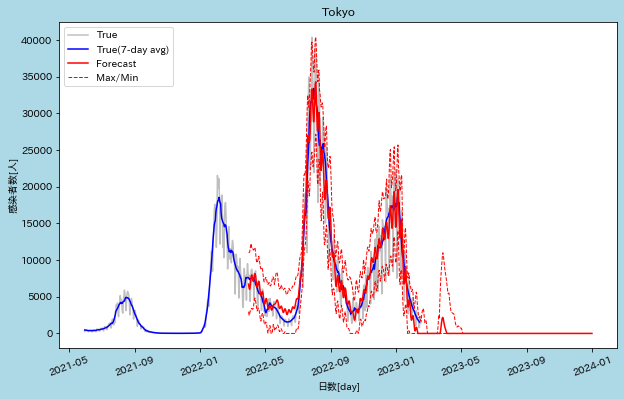

In [112]:
fig = plt.figure(figsize = (10,6), facecolor='lightblue')

#グラフを描画するsubplot領域を作成。
ax1 = fig.add_subplot(1, 1, 1)
ax=[ax1]

ax1.set_xlabel('日数[day]')
ax1.tick_params(axis='x', labelrotation=20)
ax1.set_ylabel('感染者数[人]')
ax1.plot(rv.index,rv.to_numpy().tolist(),alpha=0.5,color="gray")

ax1.plot(rvavg.index,rvavg.to_numpy().tolist(),color="blue")
ax1.plot(p.index,p.to_numpy().tolist(),color="red")
ax1.plot(max.index,max.to_numpy().tolist(),color="red",linestyle="dashed",linewidth=1)
ax1.plot(min.index,min.to_numpy().tolist(),color="red",linestyle="dashed",linewidth=1)

ax1.set_title("Tokyo")
ax1.legend(['True','True(7-day avg)',"Forecast","Max/Min"], loc='upper left')

plt.show()

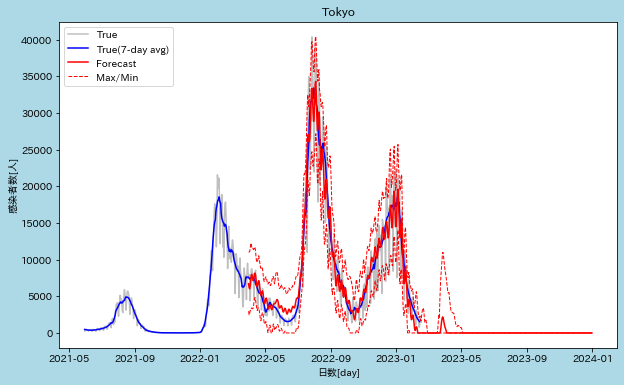

In [113]:
#Iterationを行う

limit=100 #MAEのしきい値
maxIter=3 #最大何回Iterationを行うか

InputTest_updated=InputTest.copy()
x_updated=x.copy()

cnt=1
while(1):
    #更新前と更新後のMAEを計算
    previous=np.array(InputTest_updated[StartTestingDate:][17])
    previous=(previous-LB)*(MaxV-MinV)/(UB-LB)+MinV
    previous=previous.tolist()
    now=np.array(x_updated[-((FileEndDate-StartTestingDate).days+1):][0]).tolist()
    mae=calc_MAE(previous,now)

    if mae<limit: #更新前と更新後の予測値のMAEがしきい値を下回ったならIterationを終了する
        break
    print("Iterated "+str(cnt))
    #予測に使うデータの値を更新
    InputTest_updated=InputTest.copy()

    tmp=np.array(x_updated[-((FileEndDate-StartTestingDate).days+1):][0])
    tmp=(tmp-MinV)*(UB-LB)/(MaxV-MinV)+LB
    InputTest_updated.loc[StartTestingDate:,17]=tmp

    InputTest_updated_list=InputTest_updated.to_numpy().tolist()
    TestingData_updated=[InputTest_updated_list[i:i+Days] for i in range(Dd)]

    x2_iter=model.predict(TestingData_updated) #テストデータを入力して予測

    x2norm_iter=(x2_iter-LB)*(MaxV-MinV)/(UB-LB)+MinV #予測結果を逆正規化して単位を[人]に
    #すべてnanで埋まったからの行列x3を作成
    a_iter,b_iter=np.shape(x2norm_iter)
    x3_iter=np.empty((a_iter+b_iter-1,b_iter))
    x3_iter[:]=np.nan
    #予測結果を代入し、何日のデータが何人と予測されたかわかりやすくする
    for i in range(b_iter):
        x3_iter[i:a_iter+i,i]=x2norm_iter[:,i]
    a_iter=np.average(x3_iter[Days-1:Dd,:],axis=1)
    b_iter=np.max(x3_iter[Days-1:Dd,:],axis=1)
    c_iter=np.min(x3_iter[Days-1:Dd,:],axis=1)
    d_iter=np.array([MeanCI(tmp) for tmp in x3_iter[Days-1:Dd,:]])
    a_iter[a_iter<0]=0
    b_iter[b_iter<0]=0
    c_iter[c_iter<0]=0
    d_iter[d_iter<0]=0

    x_updated=np.array([[a_iter[i],b_iter[i],c_iter[i],d_iter[i][0],d_iter[i][1]] for i in range(len(a_iter))])
    if exponentiation==10: x=exponentiation**x
    x_updated=pd.DataFrame(x_updated)
    cnt+=1
    if cnt>maxIter:
        break

adjust=(NewDate1-day_add(StartTrainingDate,26)).days
p_iter=TimeSeries(x_updated[:][[0]][adjust:],NewDate1)
max_iter=TimeSeries(x_updated[:][[1]][adjust:],NewDate1)
min_iter=TimeSeries(x_updated[:][[2]][adjust:],NewDate1)
min95_iter=TimeSeries(x_updated[:][[3]][adjust:],NewDate1)
max95_iter=TimeSeries(x_updated[:][[4]][adjust:],NewDate1)

fig = plt.figure(figsize = (10,6), facecolor='lightblue')

#グラフを描画するsubplot領域を作成。
ax1 = fig.add_subplot(1, 1, 1)
ax=[ax1]

ax1.set_xlabel('日数[day]')
#ax1.tick_params(axis='x', labelrotation=20)
ax1.set_ylabel('感染者数[人]')
ax1.plot(rv.index,rv.to_numpy().tolist(),alpha=0.5,color="gray")
ax1.plot(rvavg.index,rvavg.to_numpy().tolist(),color="blue")
ax1.plot(p_iter.index,p_iter.to_numpy().tolist(),color="red")
ax1.plot(max_iter.index,max_iter.to_numpy().tolist(),color="red",linestyle="dashed",linewidth=1)
ax1.plot(min_iter.index,min_iter.to_numpy().tolist(),color="red",linestyle="dashed",linewidth=1)
ax1.set_title("Tokyo")
ax1.legend(['True','True(7-day avg)',"Forecast","Max/Min"], loc='upper left')